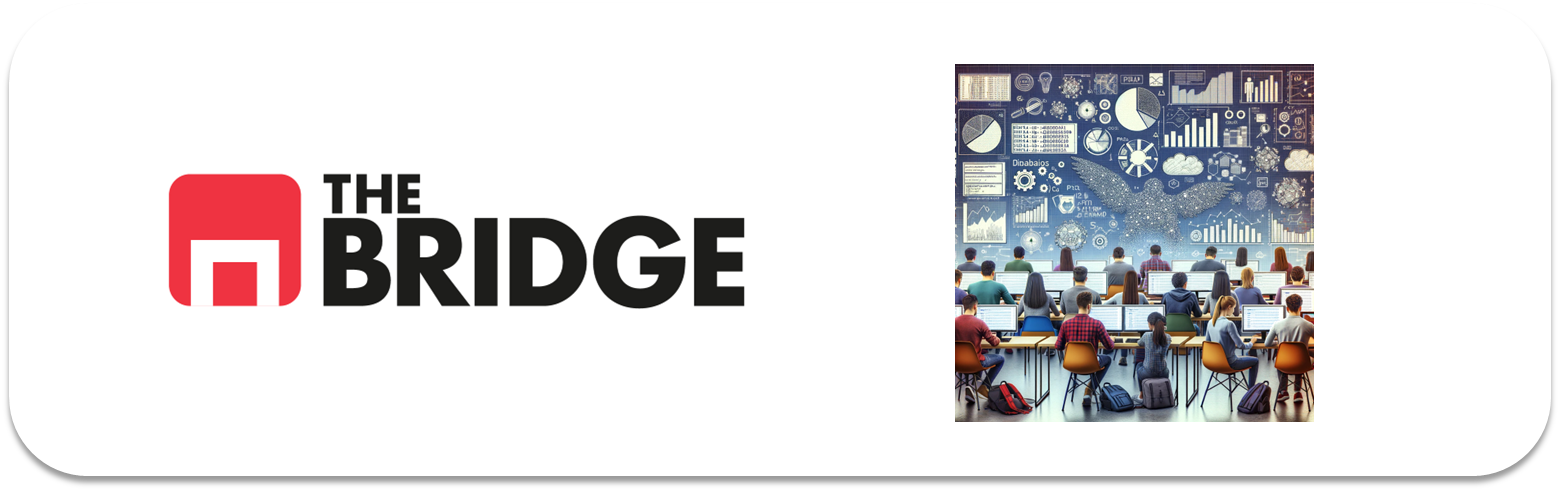

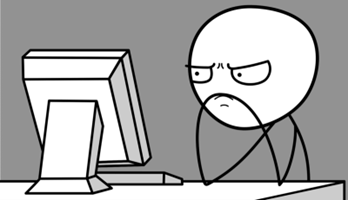

Para ejercitarte y afianzar lo aprendido sobre **Proceso de Datos**, como primera etapa de ML, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# from bootcampviztools import pinta_distribucion_categoricas, plot_categorical_numerical_relationship, plot_grouped_histograms
from sklearn.model_selection import train_test_split

### Ejercicio 1

Carga el dataset de advertising que encontrarás en la carpeta de datos. Muestra su información general. ¿Qué te llama la atención? ¿Tendremos que limpiar alguna variable?

In [4]:
df = pd.read_csv("./data/advertising_ml.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   object 
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 78.2+ KB


In [5]:
df

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35 years,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31 years,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26 years,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29 years,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35 años,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0
...,...,...,...,...,...,...,...,...,...,...
995,72.97,30 years,71384.57,208.58,Fundamental modular algorithm,Duffystad,1,Lebanon,2016-02-11 21:49:00,1
996,51.30,45 años,67782.17,134.42,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,2016-04-22 02:07:01,1
997,51.63,51 years,42415.72,120.37,Expanded intangible solution,South Jessica,1,Mongolia,2016-02-01 17:24:57,1
998,55.55,19 years,41920.79,187.95,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,2016-03-24 02:35:54,0


En principio detectados 2 errores:
- Age está como texto con mezcla de idiomas: hay que extarer el número y convertir a entero
- Timestamp es string, no datatime: hay que hacer la conversioón y extraer las features derivadas com la hora del día o el día de la semana

In [7]:
# En 'Age' extrae el dígito y convierte a int
df["Age"] = df["Age"].str.extract(r'(\d+)').astype(int)

# Convertir a datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extraer features temporales
df['Hour']      = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek  # 0 = lunes
df['Month']     = df['Timestamp'].dt.month

# Descartar la columna original
df = df.drop(columns=['Timestamp'])

### Ejercicio 2

Tenemos que entender el problema antes de seguir. Nos dicen que la compañía "QuickRespond" quiere poder generar un modelo que a partir de datos como los del dataset para poder dirigir mejor su campaña de anuncios. Hablando con ellos llegamos a la conclusión de que queremos un modelo para poder predecir si un usuario pulsará en el link de un anuncio o no. ¿Qué tipo de problemas estamos tratando?¿Y de que tipo de aprendizaje?¿Existe una variable target que puedas identificar rapidamente?

- Es un problema de clasificación binaria: queremos predecir si un usuario hará clic en un anuncio(1) o no(0). Solo hay dos clases posibles, de ahí do de "binaria"
- El tipo de aprendizaje es supervisado, porque cada fila del dataset ya tiene la respuesta en la columna 'Clicked on Ad'
- La variable target se identifica de inmediato: 'Clickes on Ad', que toma valores 0 o 1.

### Ejercicio 3

Volvamos ya a los datos. Intenta dar una definicón de cada columna, obten su cardinalidad y en función de esta y del tipo de variable de pandas, clasifícalas en categóricas y numéricas.

In [8]:
df_tipificacion = pd.DataFrame([df.nunique(), df.nunique()/len(df)*100, df.dtypes]).T.rename(columns={0:"Card", 1:"%_Card",2:"Tipo"})
df_tipificacion.head(14)

,Card,%_Card,Tipo
Daily Time Spent on Site,900,90.0,float64
Age,43,4.3,int64
Area Income,1000,100.0,float64
Daily Internet Usage,966,96.6,float64
Ad Topic Line,1000,100.0,object
City,969,96.9,object
Male,2,0.2,int64
Country,237,23.7,object
Clicked on Ad,2,0.2,int64
Hour,24,2.4,int32


In [12]:
df_tipificacion["Clasificada_como"] = "Categórica"
df_tipificacion.loc[df_tipificacion.Card == 2, "Clasificada_como"] = "Binaria"

# Solo aplicar reglas numéricas a columnas que no sean texto (object)
mask_num = df_tipificacion["Tipo"] != "object"
df_tipificacion.loc[mask_num & (df_tipificacion.Card > 10), "Clasificada_como"] = "Numérica Discreta"
df_tipificacion.loc[mask_num & (df_tipificacion["%_Card"] > 25), "Clasificada_como"] = "Numérica Continua"

# Texto con alta cardinalidad → no es numérica, es categórica especial
df_tipificacion.loc[
    (df_tipificacion.Tipo == "object") & (df_tipificacion.Card > 10),
    "Clasificada_como"
] = "Categórica (alta cardinalidad)"

df_tipificacion

,Card,%_Card,Tipo,Clasificada_como
Daily Time Spent on Site,900,90.0,float64,Numérica Continua
Age,43,4.3,int64,Numérica Discreta
Area Income,1000,100.0,float64,Numérica Continua
Daily Internet Usage,966,96.6,float64,Numérica Continua
Ad Topic Line,1000,100.0,object,Categórica (alta cardinalidad)
City,969,96.9,object,Categórica (alta cardinalidad)
Male,2,0.2,int64,Binaria
Country,237,23.7,object,Categórica (alta cardinalidad)
Clicked on Ad,2,0.2,int64,Binaria
Hour,24,2.4,int32,Numérica Discreta


### Ejercicio 4

Limpia las columnas que necesiten ser limpiadas, no completes nulos (porque asignar valores a nulos sólo puedes hacerlo primero con el train, ya explicaremos con detalle por qué). 

In [11]:
print(df.dtypes)
print(df.isnull().sum())

Daily Time Spent on Site    float64
Age                           int64
Area Income                 float64
Daily Internet Usage        float64
Ad Topic Line                object
City                         object
Male                          int64
Country                      object
Clicked on Ad                 int64
Hour                          int32
DayOfWeek                     int32
Month                         int32
dtype: object
Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Clicked on Ad               0
Hour                        0
DayOfWeek                   0
Month                       0
dtype: int64


Dataset limpio y listo

### Ejercicio 5

Divide el datset en train y test, empleando sklearn para ello tal y como hemos hecho en el workout. Usa la regla del 80-20

In [13]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

### Ejercicio 6

Haz un pequeño análisis univariante de las columnas numéricas (muestra sus histogramas)

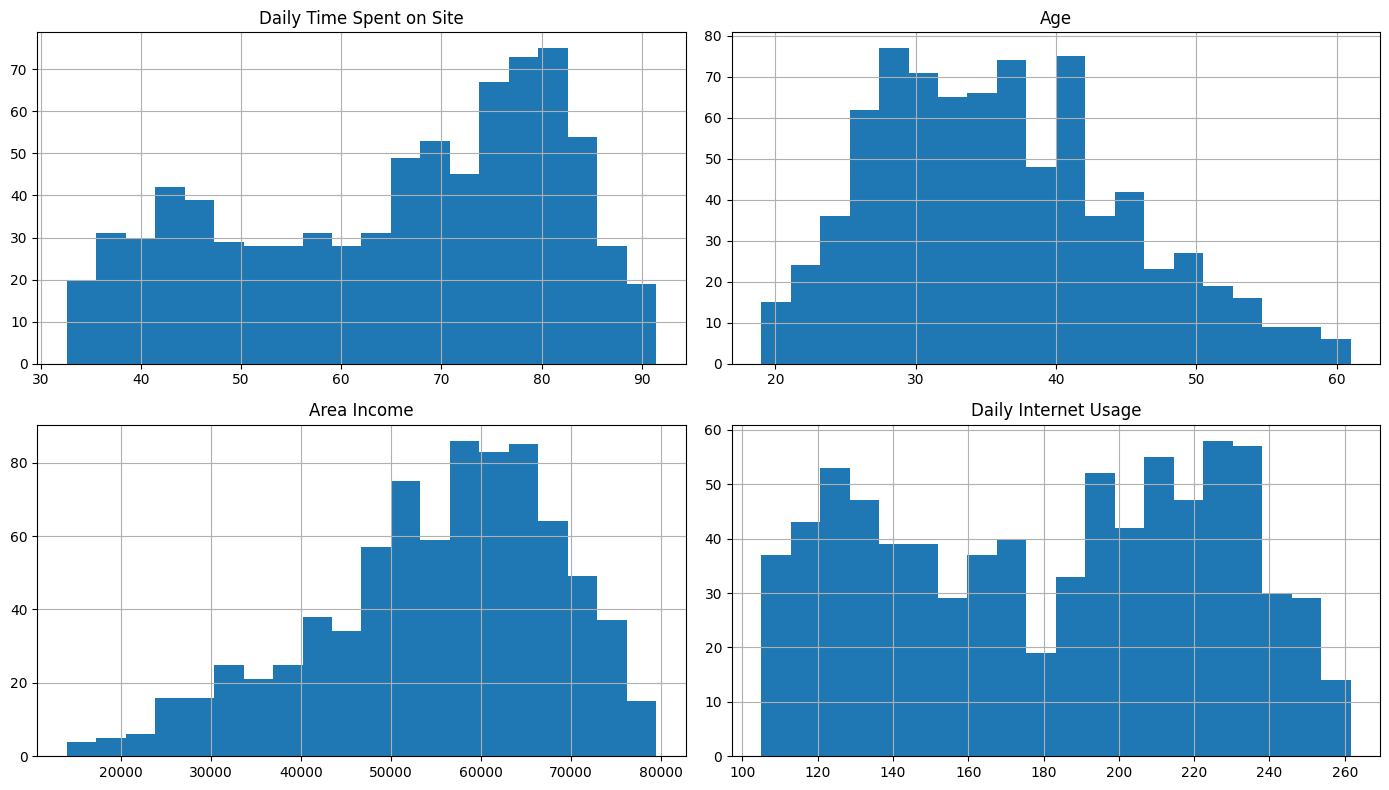

In [14]:
num_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

train_set[num_cols].hist(bins=20, figsize=(14, 8))
plt.tight_layout()
plt.show()

### Ejercicio 7

Muestra las correlaciones de las variables continuas con un "PairPlot" y emplea como codigo de color la variable target. [Esto es otra forma de hacer un bivariante y un multivariante a la vez]. Para ello como argumento del pairplot de seaborn usa el dataframe de train (no la matriz de correlación)

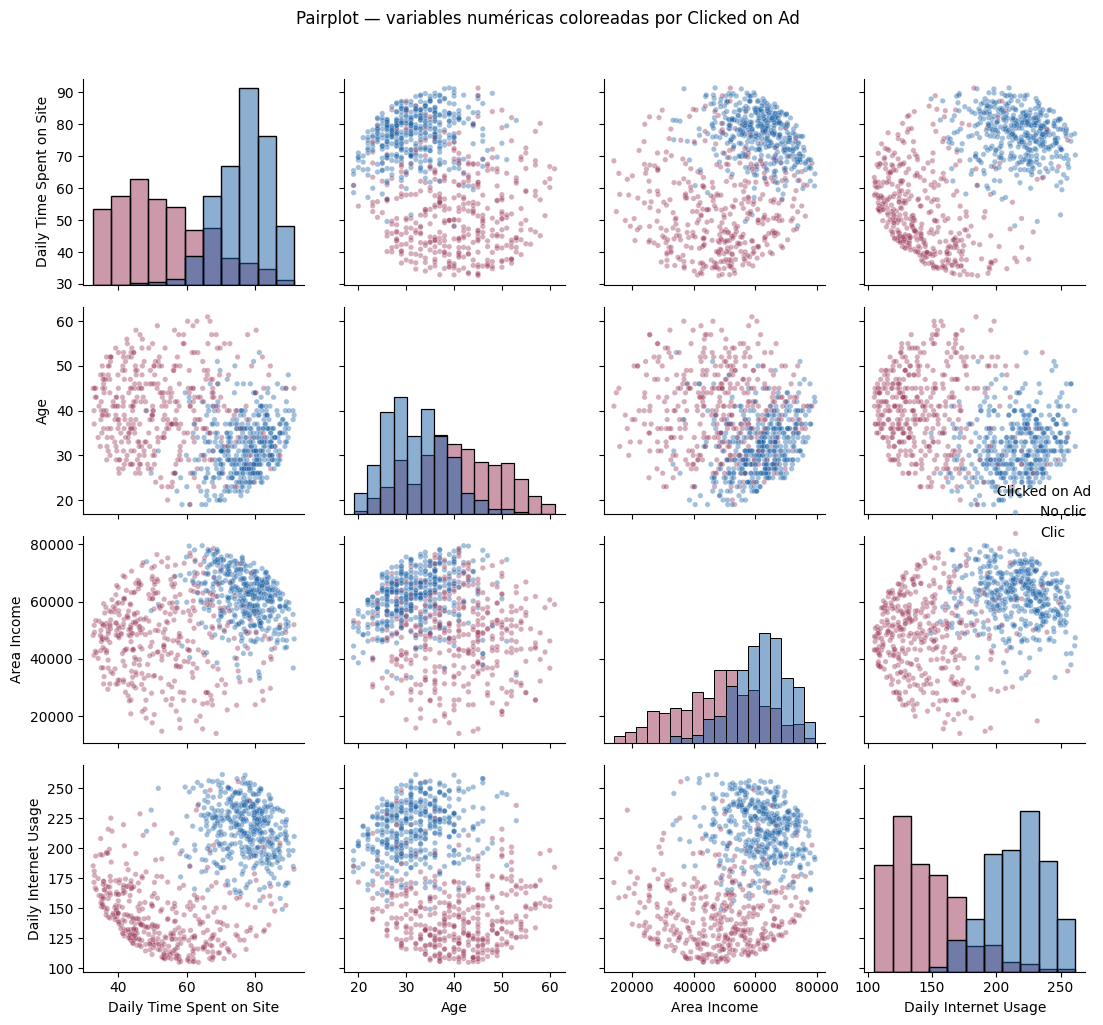

In [15]:
train_pp = train_set[num_cols + ['Clicked on Ad']].copy()
train_pp['Clicked on Ad'] = train_pp['Clicked on Ad'].map({0: 'No clic', 1: 'Clic'})

sns.pairplot(train_pp, hue='Clicked on Ad',
             palette={'No clic': '#185FA5', 'Clic': '#993556'},
             plot_kws={'alpha': 0.4, 's': 15},
             diag_kind='hist')
plt.suptitle('Pairplot — variables numéricas coloreadas por Clicked on Ad', y=1.02)
plt.tight_layout()
plt.show()

### Ejercicio 8

Fijándote en la diagonal principal del gráfico anterior haz una selecció de features:

In [16]:
features_seleccionadas = [
    'Daily Time Spent on Site',   # separación muy clara
    'Daily Internet Usage',        # la más discriminante
    'Age'                          # separación moderada, aporta señal
]